# Model BiLSTM

Eksperimen empiris, simulasi, dan penyeimbangan kelas BiLSTM.


In [ ]:
# Jalankan 01_preprocessing.ipynb terlebih dahulu.
import pickle
import pandas as pd

data_new = pd.read_pickle("data_preprocessed_with_emoticon.pkl")
with open("split_data.pkl", "rb") as file:
    split_data = pickle.load(file)

X_train_lstm = split_data["X_train_lstm"]
X_test_lstm = split_data["X_test_lstm"]
X_train_bert = split_data["X_train_bert"]
X_test_bert = split_data["X_test_bert"]
y_train = split_data["y_train"]
y_test = split_data["y_test"]


#BAGIAN 3 — Data Empiris biLSTM


In [ ]:
# =====================================================
# BiLSTM EMPIRIS DENGAN VALIDATION STRATIFIED
# =====================================================

import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

# Set seed
seed = 42
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

# Parameter
max_words = 10000
max_len = 50

In [ ]:
print(X_train_lstm.shape)
print(X_test_lstm.shape)
print(y_train.shape)
print(y_test.shape)

print(y_train.value_counts().sort_index())
print(y_test.value_counts().sort_index())

(6918,)
(1730,)
(6918,)
(1730,)
label
0.0    3874
1.0    1172
2.0    1872
Name: count, dtype: int64
label
0.0    969
1.0    293
2.0    468
Name: count, dtype: int64


In [ ]:
# =====================================================
# SPLIT TRAIN MENJADI TRAIN FINAL DAN VALIDATION
# =====================================================

X_train_lstm_final, X_val_lstm, y_train_lstm_final, y_val_lstm = train_test_split(
    X_train_lstm,
    y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=42
)

print("Distribusi train final:")
print(y_train_lstm_final.value_counts().sort_index())

print("\nDistribusi validation:")
print(y_val_lstm.value_counts().sort_index())

print("\nDistribusi test:")
print(y_test.value_counts().sort_index())

Distribusi train final:
label
0.0    3486
1.0    1055
2.0    1685
Name: count, dtype: int64

Distribusi validation:
label
0.0    388
1.0    117
2.0    187
Name: count, dtype: int64

Distribusi test:
label
0.0    969
1.0    293
2.0    468
Name: count, dtype: int64


In [ ]:
# =====================================================
# TOKENIZER
# =====================================================

tokenizer_lstm = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

tokenizer_lstm.fit_on_texts(X_train_lstm_final)

X_train_seq = tokenizer_lstm.texts_to_sequences(X_train_lstm_final)
X_val_seq = tokenizer_lstm.texts_to_sequences(X_val_lstm)
X_test_seq = tokenizer_lstm.texts_to_sequences(X_test_lstm)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding='post'
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=max_len,
    padding='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding='post'
)

print("Shape train:", X_train_pad.shape)
print("Shape val  :", X_val_pad.shape)
print("Shape test :", X_test_pad.shape)

Shape train: (6226, 50)
Shape val  : (692, 50)
Shape test : (1730, 50)


In [ ]:
# =====================================================
# BUILD MODEL BiLSTM
# =====================================================

K.clear_session()
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

model_bilstm_emp = Sequential()

model_bilstm_emp.add(
    Embedding(
        input_dim=max_words,
        output_dim=128,
        input_length=max_len
    )
)

model_bilstm_emp.add(
    Bidirectional(
        LSTM(64)
    )
)

model_bilstm_emp.add(
    Dropout(0.3)
)

model_bilstm_emp.add(
    Dense(64, activation='relu')
)

model_bilstm_emp.add(
    Dense(3, activation='softmax')
)

model_bilstm_emp.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model_bilstm_emp.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning:

Argument `input_length` is deprecated. Just remove it.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# =====================================================
# TRAINING
# =====================================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_bilstm_emp = model_bilstm_emp.fit(
    X_train_pad,
    y_train_lstm_final,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_pad, y_val_lstm),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6828 - loss: 0.7664 - val_accuracy: 0.7673 - val_loss: 0.6137
Epoch 2/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8370 - loss: 0.4571 - val_accuracy: 0.7587 - val_loss: 0.5968
Epoch 3/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8967 - loss: 0.3084 - val_accuracy: 0.7038 - val_loss: 0.7952
Epoch 4/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9327 - loss: 0.2137 - val_accuracy: 0.7240 - val_loss: 0.8513
Epoch 5/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9452 - loss: 0.1726 - val_accuracy: 0.7399 - val_loss: 0.9907


55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

=== CLASSIFICATION REPORT — BiLSTM EMPIRIS ===
              precision    recall  f1-score   support

     negatif       0.86      0.83      0.85       969
      netral       0.50      0.56      0.53       293
     positif       0.77      0.77      0.77       468

    accuracy                           0.77      1730
   macro avg       0.71      0.72      0.72      1730
weighted avg       0.78      0.77      0.77      1730



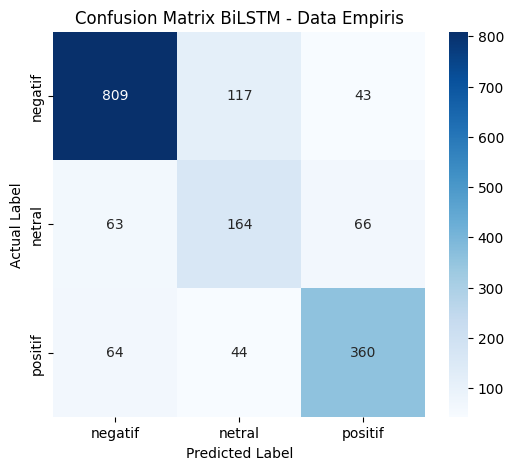

    Model     Data  Accuracy  Precision Macro  Recall Macro  Macro F1
0  BiLSTM  Empiris   0.77052         0.712174       0.72128  0.716166


In [ ]:
# =====================================================
# EVALUASI TEST
# =====================================================

y_pred_bilstm_emp = np.argmax(
    model_bilstm_emp.predict(X_test_pad),
    axis=1
)

label_names = ['negatif', 'netral', 'positif']

print("\n=== CLASSIFICATION REPORT — BiLSTM EMPIRIS ===")
print(classification_report(
    y_test,
    y_pred_bilstm_emp,
    target_names=label_names,
    zero_division=0
))

cm_bilstm_emp = confusion_matrix(
    y_test,
    y_pred_bilstm_emp
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_bilstm_emp,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names
)

plt.title("Confusion Matrix BiLSTM - Data Empiris")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

accuracy = accuracy_score(
    y_test,
    y_pred_bilstm_emp
)

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_test,
    y_pred_bilstm_emp,
    average='macro',
    zero_division=0
)

hasil_bilstm_emp = pd.DataFrame({
    "Model": ["BiLSTM"],
    "Data": ["Empiris"],
    "Accuracy": [accuracy],
    "Precision Macro": [precision_macro],
    "Recall Macro": [recall_macro],
    "Macro F1": [f1_macro]
})

print(hasil_bilstm_emp)

hasil_bilstm_emp.to_csv(
    "hasil_bilstm_empiris_with_emoticon_stratified_val.csv",
    index=False
)

#BAGIAN 5 — Data Simulasi biLSTM


In [ ]:
# =====================================================
# 1. IMPORT LIBRARY
# =====================================================

import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout,
    Bidirectional
)

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

In [ ]:
# =====================================================
# 2. SET SEED
# =====================================================

seed = 42

np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

max_words = 10000
max_len = 50

In [ ]:
# =====================================================
# 3. GABUNGKAN DATA TRAIN
# =====================================================
# Data simulasi hanya dibentuk dari data latih.
# Jangan mengambil dari seluruh data agar tidak terjadi data leakage.

train_df = pd.DataFrame({
    'text': X_train_lstm.reset_index(drop=True),
    'label': y_train.reset_index(drop=True)
})

print("Distribusi data train:")
print(train_df['label'].value_counts().sort_index())

print("\nKeterangan label:")
print("0 = negatif")
print("1 = netral")
print("2 = positif")

Distribusi data train:
label
0.0    3874
1.0    1172
2.0    1872
Name: count, dtype: int64

Keterangan label:
0 = negatif
1 = netral
2 = positif


In [ ]:
# =====================================================
# 4. HITUNG JUMLAH SKENARIO BERDASARKAN DATA TRAIN
# =====================================================
# Rasio disusun mengikuti kondisi empiris:
# negatif = mayoritas
# positif = sedang
# netral = minoritas
#
# Jadi untuk skenario tidak seimbang:
# 6:3:1 = negatif : positif : netral
# 8:1:1 = negatif : positif : netral

train_counts = train_df['label'].value_counts().sort_index()

n_neg = train_counts[0]
n_net = train_counts[1]
n_pos = train_counts[2]

print("Jumlah data train:")
print("Negatif:", n_neg)
print("Netral :", n_net)
print("Positif:", n_pos)

# =====================================================
# Skenario 1:1:1
# =====================================================

base_111 = min(n_neg, n_net, n_pos)

n_111_neg = base_111
n_111_net = base_111
n_111_pos = base_111

# =====================================================
# Skenario 6:3:1
# Rasio substantif: negatif : positif : netral
# =====================================================

base_631 = min(
    n_neg // 6,
    n_pos // 3,
    n_net // 1
)

n_631_neg = 6 * base_631
n_631_pos = 3 * base_631
n_631_net = 1 * base_631

# =====================================================
# Skenario 8:1:1
# Rasio substantif: negatif : positif : netral
# =====================================================

base_811 = min(
    n_neg // 8,
    n_pos // 1,
    n_net // 1
)

n_811_neg = 8 * base_811
n_811_pos = 1 * base_811
n_811_net = 1 * base_811

print("\n=== JUMLAH DATA SIMULASI ===")

print("\nSkenario 1:1:1")
print("Negatif:", n_111_neg)
print("Netral :", n_111_net)
print("Positif:", n_111_pos)
print("Total  :", n_111_neg + n_111_net + n_111_pos)

print("\nSkenario 6:3:1")
print("Negatif:", n_631_neg)
print("Netral :", n_631_net)
print("Positif:", n_631_pos)
print("Total  :", n_631_neg + n_631_net + n_631_pos)

print("\nSkenario 8:1:1")
print("Negatif:", n_811_neg)
print("Netral :", n_811_net)
print("Positif:", n_811_pos)
print("Total  :", n_811_neg + n_811_net + n_811_pos)

Jumlah data train:
Negatif: 3874
Netral : 1172
Positif: 1872

=== JUMLAH DATA SIMULASI ===

Skenario 1:1:1
Negatif: 1172
Netral : 1172
Positif: 1172
Total  : 3516

Skenario 6:3:1
Negatif: 3744
Netral : 624
Positif: 1872
Total  : 6240

Skenario 8:1:1
Negatif: 3872
Netral : 484
Positif: 484
Total  : 4840


In [ ]:
# =====================================================
# 5. FUNGSI MEMBUAT SKENARIO
# =====================================================

def buat_skenario(df, n_neg, n_net, n_pos, random_state=42):

    neg = df[df['label'] == 0].sample(
        n=n_neg,
        random_state=random_state,
        replace=False
    )

    net = df[df['label'] == 1].sample(
        n=n_net,
        random_state=random_state,
        replace=False
    )

    pos = df[df['label'] == 2].sample(
        n=n_pos,
        random_state=random_state,
        replace=False
    )

    result = pd.concat([neg, net, pos])

    result = result.sample(
        frac=1,
        random_state=random_state
    ).reset_index(drop=True)

    return result

In [ ]:
# =====================================================
# 6. MEMBUAT DATA SIMULASI
# =====================================================

skenario_111 = buat_skenario(
    train_df,
    n_neg=n_111_neg,
    n_net=n_111_net,
    n_pos=n_111_pos,
    random_state=42
)

skenario_631 = buat_skenario(
    train_df,
    n_neg=n_631_neg,
    n_net=n_631_net,
    n_pos=n_631_pos,
    random_state=42
)

skenario_811 = buat_skenario(
    train_df,
    n_neg=n_811_neg,
    n_net=n_811_net,
    n_pos=n_811_pos,
    random_state=42
)

In [ ]:
# =====================================================
# 7. CEK DISTRIBUSI SKENARIO
# =====================================================

print("=== SKENARIO 1:1:1 ===")
print(skenario_111['label'].value_counts().sort_index())

print("\n=== SKENARIO 6:3:1 ===")
print(skenario_631['label'].value_counts().sort_index())

print("\n=== SKENARIO 8:1:1 ===")
print(skenario_811['label'].value_counts().sort_index())

=== SKENARIO 1:1:1 ===
label
0.0    1172
1.0    1172
2.0    1172
Name: count, dtype: int64

=== SKENARIO 6:3:1 ===
label
0.0    3744
1.0     624
2.0    1872
Name: count, dtype: int64

=== SKENARIO 8:1:1 ===
label
0.0    3872
1.0     484
2.0     484
Name: count, dtype: int64


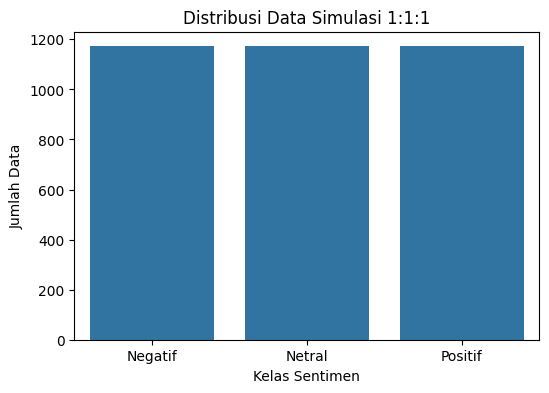

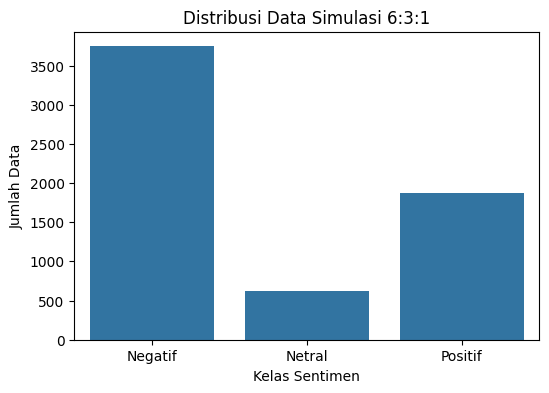

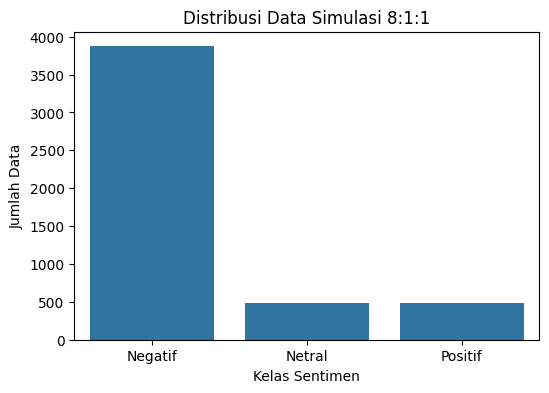

In [ ]:
# =====================================================
# 8. VISUALISASI DISTRIBUSI SKENARIO
# =====================================================

def plot_distribusi_skenario(df, nama_skenario):

    counts = df['label'].value_counts().sort_index()
    label_names = ['Negatif', 'Netral', 'Positif']

    y_values = [
        counts.get(0, 0),
        counts.get(1, 0),
        counts.get(2, 0)
    ]

    plt.figure(figsize=(6, 4))
    sns.barplot(
        x=label_names,
        y=y_values
    )

    plt.title(f"Distribusi Data Simulasi {nama_skenario}")
    plt.xlabel("Kelas Sentimen")
    plt.ylabel("Jumlah Data")
    plt.show()

plot_distribusi_skenario(skenario_111, "1:1:1")
plot_distribusi_skenario(skenario_631, "6:3:1")
plot_distribusi_skenario(skenario_811, "8:1:1")

In [ ]:
# =====================================================
# 10. FUNGSI TRAINING DAN EVALUASI BiLSTM
# =====================================================

def train_bilstm_skenario(skenario_df, nama_skenario):

    print(f"\n{'='*60}")
    print(f"BiLSTM - SKENARIO {nama_skenario}")
    print(f"{'='*60}")

    K.clear_session()
    tf.random.set_seed(42)
    np.random.seed(42)
    random.seed(42)

    # =================================================
    # Ambil data simulasi
    # =================================================

    X_train_sim = skenario_df['text']
    y_train_sim = skenario_df['label']

    # =================================================
    # Split train-validation secara stratified
    # =================================================

    X_train_sim_final, X_val_sim, y_train_sim_final, y_val_sim = train_test_split(
        X_train_sim,
        y_train_sim,
        test_size=0.1,
        stratify=y_train_sim,
        random_state=42
    )

    print("Distribusi train simulasi final:")
    print(y_train_sim_final.value_counts().sort_index())

    print("\nDistribusi validation simulasi:")
    print(y_val_sim.value_counts().sort_index())

    # =================================================
    # Tokenizer dari train final simulasi
    # =================================================

    tokenizer_sim = Tokenizer(
        num_words=max_words,
        oov_token="<OOV>"
    )

    tokenizer_sim.fit_on_texts(X_train_sim_final)

    X_train_seq = tokenizer_sim.texts_to_sequences(X_train_sim_final)
    X_val_seq = tokenizer_sim.texts_to_sequences(X_val_sim)
    X_test_seq = tokenizer_sim.texts_to_sequences(X_test_lstm)

    X_train_pad = pad_sequences(
        X_train_seq,
        maxlen=max_len,
        padding='post'
    )

    X_val_pad = pad_sequences(
        X_val_seq,
        maxlen=max_len,
        padding='post'
    )

    X_test_pad = pad_sequences(
        X_test_seq,
        maxlen=max_len,
        padding='post'
    )

    # =================================================
    # Build model BiLSTM
    # =================================================

    model = Sequential()

    model.add(
        Embedding(
            input_dim=max_words,
            output_dim=128,
            input_length=max_len
        )
    )

    model.add(
        Bidirectional(
            LSTM(64)
        )
    )

    model.add(
        Dropout(0.3)
    )

    model.add(
        Dense(64, activation='relu')
    )

    model.add(
        Dense(3, activation='softmax')
    )

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=Adam(learning_rate=0.001),
        metrics=['accuracy']
    )

    # =================================================
    # Early stopping
    # =================================================

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    # =================================================
    # Training
    # =================================================

    history = model.fit(
        X_train_pad,
        y_train_sim_final,
        epochs=20,
        batch_size=32,
        validation_data=(X_val_pad, y_val_sim),
        callbacks=[early_stop],
        verbose=1
    )

    # =================================================
    # Prediksi pada data test empiris
    # =================================================

    y_pred = np.argmax(
        model.predict(X_test_pad),
        axis=1
    )

    label_names = ['negatif', 'netral', 'positif']

    print("\n=== CLASSIFICATION REPORT ===")
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_names,
        zero_division=0
    ))

    # =================================================
    # Confusion matrix
    # =================================================

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=label_names,
        yticklabels=label_names
    )

    plt.title(f"Confusion Matrix BiLSTM - Skenario {nama_skenario}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.show()

    # =================================================
    # Ringkasan metrik
    # =================================================

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average='macro',
        zero_division=0
    )

    hasil = {
        "Skenario": nama_skenario,
        "Model": "BiLSTM",
        "Accuracy": accuracy,
        "Precision Macro": precision_macro,
        "Recall Macro": recall_macro,
        "Macro F1": f1_macro
    }

    return hasil, y_pred, cm, history


BiLSTM - SKENARIO 1:1:1
Distribusi train simulasi final:
label
0.0    1055
1.0    1055
2.0    1054
Name: count, dtype: int64

Distribusi validation simulasi:
label
0.0    117
1.0    117
2.0    118
Name: count, dtype: int64
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning:

Argument `input_length` is deprecated. Just remove it.



99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5009 - loss: 0.9760 - val_accuracy: 0.6506 - val_loss: 0.8236
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7803 - loss: 0.5519 - val_accuracy: 0.6534 - val_loss: 0.8676
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8903 - loss: 0.3106 - val_accuracy: 0.6364 - val_loss: 1.0764
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9355 - loss: 0.1794 - val_accuracy: 0.6449 - val_loss: 1.1990
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     negatif       0.87      0.66      0.75       969
      netral       0.38      0.70      0.50       293
     positif       0.72      0.70      0.71       468

    accuracy                           0.68      1730
   macro avg       0.66      0.69      0.65      1730
weighted avg       0.75      0.68      0.70      1730



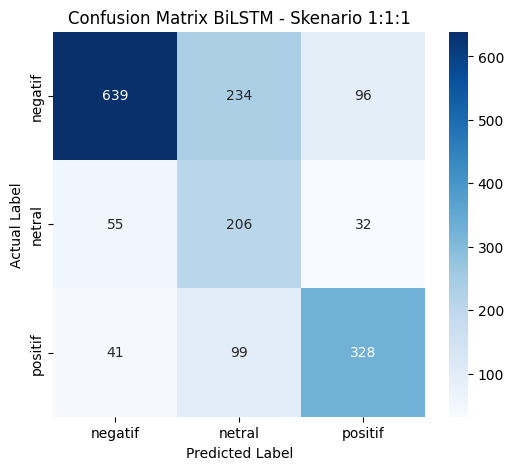

In [ ]:
# =====================================================
# 11. TRAINING SKENARIO 1:1:1
# =====================================================

hasil_111, y_pred_111, cm_111, history_111 = train_bilstm_skenario(
    skenario_111,
    "1:1:1"
)


BiLSTM - SKENARIO 6:3:1
Distribusi train simulasi final:
label
0.0    3369
1.0     562
2.0    1685
Name: count, dtype: int64

Distribusi validation simulasi:
label
0.0    375
1.0     62
2.0    187
Name: count, dtype: int64
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning:

Argument `input_length` is deprecated. Just remove it.



176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7340 - loss: 0.6905 - val_accuracy: 0.7965 - val_loss: 0.5620
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8519 - loss: 0.4093 - val_accuracy: 0.7869 - val_loss: 0.5708
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9097 - loss: 0.2670 - val_accuracy: 0.7901 - val_loss: 0.6548
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9421 - loss: 0.1837 - val_accuracy: 0.7708 - val_loss: 0.7686
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     negatif       0.73      0.98      0.84       969
      netral       0.00      0.00      0.00       293
     positif       0.75      0.71      0.73       468

    accuracy                           0.74      1730
   macro avg       0.50      0.56      0.52      1730
weighted avg       0.62      0.74      0.67      1730



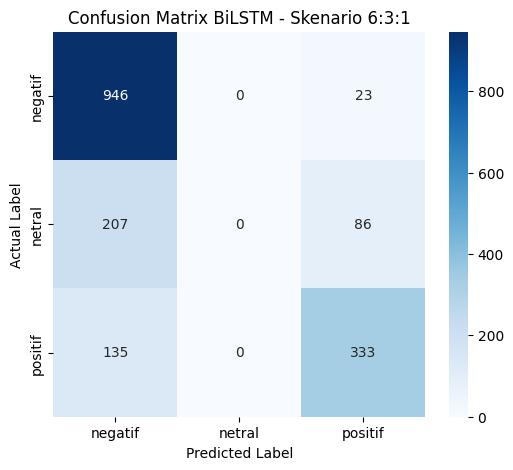

In [ ]:
# =====================================================
# 12. TRAINING SKENARIO 6:3:1
# =====================================================

hasil_631, y_pred_631, cm_631, history_631 = train_bilstm_skenario(
    skenario_631,
    "6:3:1"
)


BiLSTM - SKENARIO 8:1:1
Distribusi train simulasi final:
label
0.0    3485
1.0     435
2.0     436
Name: count, dtype: int64

Distribusi validation simulasi:
label
0.0    387
1.0     49
2.0     48
Name: count, dtype: int64
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning:

Argument `input_length` is deprecated. Just remove it.



137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8053 - loss: 0.5774 - val_accuracy: 0.8244 - val_loss: 0.4837
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8719 - loss: 0.3433 - val_accuracy: 0.8120 - val_loss: 0.4848
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9236 - loss: 0.2220 - val_accuracy: 0.8202 - val_loss: 0.5615
Epoch 4/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9580 - loss: 0.1283 - val_accuracy: 0.8182 - val_loss: 0.7238
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     negatif       0.71      0.97      0.82       969
      netral       0.00      0.00      0.00       293
     positif       0.69      0.61      0.65       468

    accuracy                           0.71      1730
   macro avg       0.47      0.53      0.49      1730
weighted avg       0.59      0.71      0.63      1730



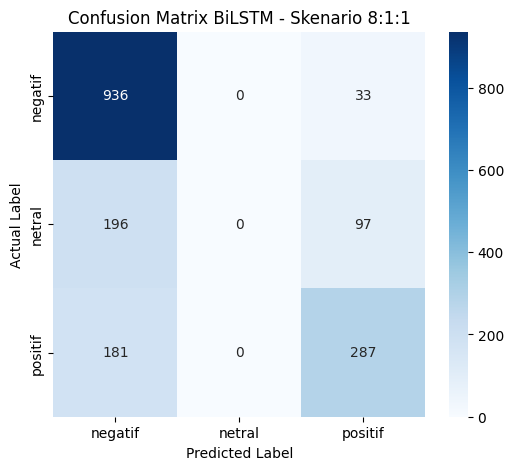

In [ ]:
# =====================================================
# 13. TRAINING SKENARIO 8:1:1
# =====================================================

hasil_811, y_pred_811, cm_811, history_811 = train_bilstm_skenario(
    skenario_811,
    "8:1:1"
)

In [ ]:
# =====================================================
# 14. RINGKASAN HASIL SEMUA SKENARIO
# =====================================================

hasil_simulasi_bilstm = pd.DataFrame([
    hasil_111,
    hasil_631,
    hasil_811
])

print(hasil_simulasi_bilstm)

hasil_simulasi_bilstm.to_csv(
    "hasil_simulasi_bilstm_with_emoticon_stratified_val.csv",
    index=False
)

  Skenario   Model  Accuracy  Precision Macro  Recall Macro  Macro F1
0    1:1:1  BiLSTM  0.678035         0.656958      0.687790  0.651716
1    6:3:1  BiLSTM  0.739306         0.495955      0.562601  0.523383
2    8:1:1  BiLSTM  0.706936         0.467040      0.526397  0.489640


In [ ]:
# =====================================================
# 15. SIMPAN PREDIKSI PER SKENARIO
# =====================================================

id2label = {
    0: "negatif",
    1: "netral",
    2: "positif"
}

prediksi_simulasi_bilstm = pd.DataFrame({
    "text": X_test_lstm.reset_index(drop=True),
    "label_aktual": y_test.reset_index(drop=True),
    "sentimen_aktual": y_test.reset_index(drop=True).map(id2label),

    "pred_111": y_pred_111,
    "sentimen_pred_111": pd.Series(y_pred_111).map(id2label),

    "pred_631": y_pred_631,
    "sentimen_pred_631": pd.Series(y_pred_631).map(id2label),

    "pred_811": y_pred_811,
    "sentimen_pred_811": pd.Series(y_pred_811).map(id2label)
})

display(prediksi_simulasi_bilstm.head())

prediksi_simulasi_bilstm.to_csv(
    "prediksi_simulasi_bilstm_with_emoticon_stratified_val.csv",
    index=False
)

,text,label_aktual,sentimen_aktual,pred_111,sentimen_pred_111,pred_631,sentimen_pred_631,pred_811,sentimen_pred_811
0,siklon tropis senyar pengaruh cuaca ekstrem su...,0.0,negatif,1,netral,0,negatif,0,negatif
1,polda aceh hadir warga tengah bencana curah hu...,2.0,positif,2,positif,2,positif,2,positif
2,lah perintah lama kocak upaya preventif lebih ...,0.0,negatif,0,negatif,0,negatif,0,negatif
3,akun komentar banjir ulang tapanuli sibolga be...,1.0,netral,1,netral,0,negatif,2,positif
4,sentil waktu panglima provinsi anjing bilang w...,0.0,negatif,0,negatif,0,negatif,0,negatif


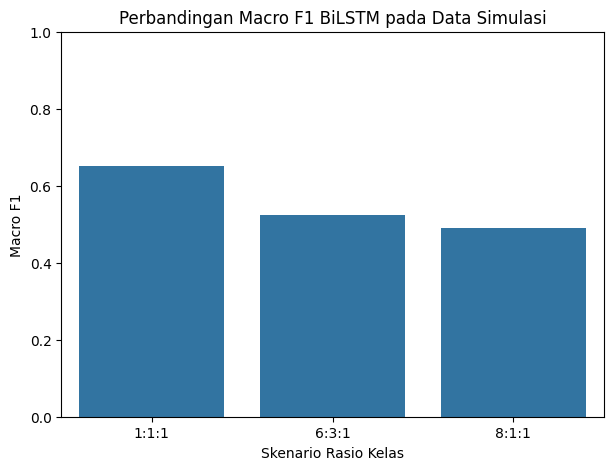

In [ ]:
# =====================================================
# 16. VISUALISASI MACRO F1 PER SKENARIO
# =====================================================

plt.figure(figsize=(7, 5))

sns.barplot(
    data=hasil_simulasi_bilstm,
    x="Skenario",
    y="Macro F1"
)

plt.title("Perbandingan Macro F1 BiLSTM pada Data Simulasi")
plt.xlabel("Skenario Rasio Kelas")
plt.ylabel("Macro F1")
plt.ylim(0, 1)
plt.show()

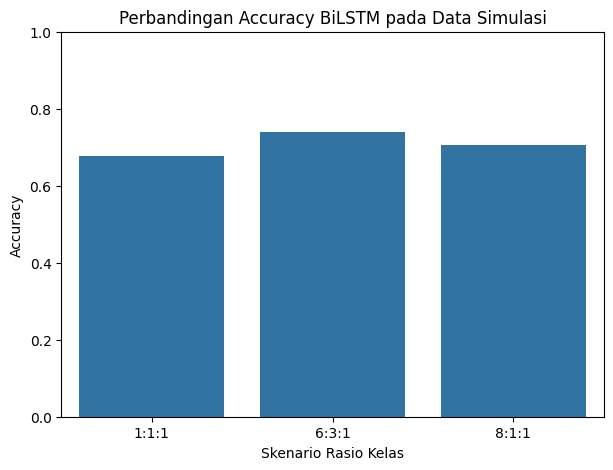

In [ ]:
# =====================================================
# 17. VISUALISASI ACCURACY PER SKENARIO
# =====================================================

plt.figure(figsize=(7, 5))

sns.barplot(
    data=hasil_simulasi_bilstm,
    x="Skenario",
    y="Accuracy"
)

plt.title("Perbandingan Accuracy BiLSTM pada Data Simulasi")
plt.xlabel("Skenario Rasio Kelas")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

#balance bilstm

In [ ]:
#CLASS WEIGHT UNTUK BiLSTM
#Import library
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

In [ ]:
#Set seed dan parameter
seed = 42

np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

max_words = 10000
max_len = 50

In [ ]:
#Split train menjadi train final dan validation secara stratified
X_train_lstm_final, X_val_lstm, y_train_lstm_final, y_val_lstm = train_test_split(
    X_train_lstm,
    y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=42
)

print("Distribusi train final:")
print(y_train_lstm_final.value_counts().sort_index())

print("\nDistribusi validation:")
print(y_val_lstm.value_counts().sort_index())

print("\nDistribusi test:")
print(y_test.value_counts().sort_index())

Distribusi train final:
label
0.0    3486
1.0    1055
2.0    1685
Name: count, dtype: int64

Distribusi validation:
label
0.0    388
1.0    117
2.0    187
Name: count, dtype: int64

Distribusi test:
label
0.0    969
1.0    293
2.0    468
Name: count, dtype: int64


In [ ]:
#Hitung class weight dari data train final
classes = np.array([0, 1, 2])

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_lstm_final
)

class_weight_dict = {
    0: class_weights_array[0],
    1: class_weights_array[1],
    2: class_weights_array[2]
}

print("Class weight:")
print(class_weight_dict)

print("\nKeterangan:")
print("0 = negatif")
print("1 = netral")
print("2 = positif")

Class weight:
{0: np.float64(0.5953337158156435), 1: np.float64(1.9671406003159557), 2: np.float64(1.2316518298714145)}

Keterangan:
0 = negatif
1 = netral
2 = positif


In [ ]:
#Tokenizer dan padding
tokenizer_lstm = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

tokenizer_lstm.fit_on_texts(X_train_lstm_final)

X_train_seq = tokenizer_lstm.texts_to_sequences(X_train_lstm_final)
X_val_seq = tokenizer_lstm.texts_to_sequences(X_val_lstm)
X_test_seq = tokenizer_lstm.texts_to_sequences(X_test_lstm)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding='post'
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=max_len,
    padding='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding='post'
)

print("Shape train:", X_train_pad.shape)
print("Shape val  :", X_val_pad.shape)
print("Shape test :", X_test_pad.shape)

Shape train: (6226, 50)
Shape val  : (692, 50)
Shape test : (1730, 50)


In [ ]:
#Build model BiLSTM dengan class weight
K.clear_session()
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

model_bilstm_cw = Sequential()

model_bilstm_cw.add(
    Embedding(
        input_dim=max_words,
        output_dim=128,
        input_length=max_len
    )
)

model_bilstm_cw.add(
    Bidirectional(
        LSTM(64)
    )
)

model_bilstm_cw.add(
    Dropout(0.3)
)

model_bilstm_cw.add(
    Dense(64, activation='relu')
)

model_bilstm_cw.add(
    Dense(3, activation='softmax')
)

model_bilstm_cw.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model_bilstm_cw.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning:

Argument `input_length` is deprecated. Just remove it.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Training dengan class weight
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_bilstm_cw = model_bilstm_cw.fit(
    X_train_pad,
    y_train_lstm_final,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_pad, y_val_lstm),
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6189 - loss: 0.8499 - val_accuracy: 0.7298 - val_loss: 0.6425
Epoch 2/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8227 - loss: 0.4904 - val_accuracy: 0.7211 - val_loss: 0.7749
Epoch 3/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8887 - loss: 0.3347 - val_accuracy: 0.6835 - val_loss: 0.9903
Epoch 4/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9210 - loss: 0.2381 - val_accuracy: 0.7095 - val_loss: 0.9639


In [ ]:
#Evaluasi BiLSTM class weight
y_pred_bilstm_cw = np.argmax(
    model_bilstm_cw.predict(X_test_pad),
    axis=1
)

label_names = ['negatif', 'netral', 'positif']

print("\n=== CLASSIFICATION REPORT — BiLSTM CLASS WEIGHT ===")
print(classification_report(
    y_test,
    y_pred_bilstm_cw,
    target_names=label_names,
    zero_division=0
))

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

=== CLASSIFICATION REPORT — BiLSTM CLASS WEIGHT ===
              precision    recall  f1-score   support

     negatif       0.88      0.75      0.81       969
      netral       0.44      0.69      0.54       293
     positif       0.77      0.74      0.75       468

    accuracy                           0.74      1730
   macro avg       0.70      0.73      0.70      1730
weighted avg       0.78      0.74      0.75      1730



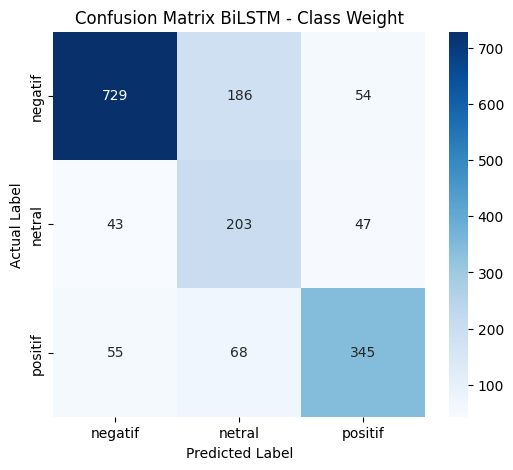

In [ ]:
#Confusion matrix BiLSTM class weight
cm_bilstm_cw = confusion_matrix(
    y_test,
    y_pred_bilstm_cw
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_bilstm_cw,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names
)

plt.title("Confusion Matrix BiLSTM - Class Weight")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [ ]:
#Ringkasan metrik BiLSTM class weight
accuracy = accuracy_score(
    y_test,
    y_pred_bilstm_cw
)

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_test,
    y_pred_bilstm_cw,
    average='macro',
    zero_division=0
)

hasil_bilstm_cw = pd.DataFrame({
    "Model": ["BiLSTM"],
    "Perlakuan": ["Class Weight"],
    "Accuracy": [accuracy],
    "Precision Macro": [precision_macro],
    "Recall Macro": [recall_macro],
    "Macro F1": [f1_macro]
})

print(hasil_bilstm_cw)

hasil_bilstm_cw.to_csv(
    "hasil_bilstm_class_weight.csv",
    index=False
)

    Model     Perlakuan  Accuracy  Precision Macro  Recall Macro  Macro F1
0  BiLSTM  Class Weight   0.73815         0.699748      0.727445  0.702687
